# Practica 04: Analisis de Datos Exploratorio con Python y Jupiter Notebook en un Dataset de Productos de Amazon store

**Programa de Estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales\
**Asignatura:** Analitica de Datos para Negocios Digitales \
**Docente:** M.T.I. Marco A. Ramirez Hernández \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparacion de los Datos

**Nombre del estudiante:** Michelle De La Cruz Rosalino \
**Matricula:** 230091 \
**Grado y Grupo:** 9A IEVND

<div style="background: linear-gradient(135deg, #BF91F8 0%, #232F3E 100%); padding: 30px;border-radius: 15px; text-align: center;margin-bottom:20px;"><h1 style="color: white; font-size: 2.2em; margin: 0;"> Productos de Amazon Store - Analisis Exploratorio de Datos Completo & Aprendizaje Automatico Predictivo (ML)</h1>
<p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">Prediccion de Precisos - Analisis de Categorias - Ingenieria de Funcionalidades - Comparacion de Modeles</p>
</div>

## Tabla de Contenidos
| # | seccion | Descripcion |
|---|---|---|
| 1 | [Instalaciones y carga de Datos](#s1) | Librerias, carga de CSV, Primeros comandos de estructura |
| 2 | [Diccionario de Datos](#s2) | Explicacion del contenido columnas y calcular el % de datos faltantes |
|3|[Limpieza de datos](#s3)|análisis de precios, valores faltantes, duplicados.|
|4|[Feature Engineering](#s4)|Características del texto, indicadores de categoría, niveles de precios|
|5|[Análisis univariado (Univariate Analysis](#s5)|Distribuciones, valores atípicos, pruebas de normalidad|
|6|[Análisis de categorías (Category Analysis)](#s6)|Categorías principales, precio por categoría|
|7|[Availability Analysis](#s7)|Patrones de estado de existencias|
|8|[Análisis de correlación y bivariado](#s8)|Mapa de calor, diagramas de dispersión|

## Instalaciones & carga de Datos <a id='s1'></a>

<div style="background:#BF91F8; padding:12px; border-left:4px solid #780808; BORDER-RADIUS:5px00; color: #FFFFFF;">
<b>Dataset:</b>Amazon India Lista de Productos - 1,436 productos entre Libros, Kindle, Deportes & mas<br>
<b>Objetivo:</b> Predecir el Precio del Producto (INR) desde la categoria, longitud del nombre, y disponibilidad <br>
<b>DataSource:</b> Web-scraped de paginas de productos Amazon.in
</div>

In [1]:

# ============================================================
# SECTION 1 — Setup & Data Loading
# ============================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import shapiro, kruskal, spearmanr, mannwhitneyu, f_oneway

# ML
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f'✅ Pandas  : {pd.__version__}')
print(f'✅ NumPy   : {np.__version__}')
print(f'✅ XGBoost : {XGB_AVAILABLE}')
print('✅Todas las librerias cargaron con exito!')

✅ Pandas  : 2.3.3
✅ NumPy   : 2.3.5
✅ XGBoost : False
✅Todas las librerias cargaron con exito!


In [2]:
# Load dataset

df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f' 📦 Shape    : {df_raw.shape}')
print(f' 📋 Columns  : {df_raw.columns.tolist()}')
df_raw.head(3)


 📦 Shape    : (1445, 17)
 📋 Columns  : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de Datos del Data Frame.

In [3]:
# column dictionary
col_info = {
    'rl' : 'URL del producto en Amazon. in',
    'asin' : 'Numero Estabderizado de Identificacion por Amazon (Unique ID)',
    'name' : 'Nombre o Titulo del Producto',
    'overview' : 'Breve Reseña del Producto (Mayoria vacio [])',
    'price' : 'Precio como string (e.g "1,600.00")',
    'currency' : 'Codigo de Divisa (todas en INR)',
    'availability' : 'Texto del Status del Stock (Inventario)',
    'brand' : 'Nombre de la Marca / Autor',
    'about_item' : 'Detalles / Especificaciones (mayoria faltante)',
    'img_source' : 'URLs de Imagines del Producto',
    'description' : 'Descripcion detallada y completa (mayoria faltante)',
    'specifications' : 'Especificaciones Tecnicas',
    'primary_category' : 'Categoria Principal (Libros, Kindle, Deportes...)',
    'category_1' : 'subcategoria de nivel 1',
    'category_2' : 'subcategoria de nivel 2',
    'category_3' : 'subcategoria de nivel 3',
    'breadcrumbs' : 'Ruta de Categorias',
}
print('📖 Diccionario por columnas: ')
for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(
        f'{col:20s} | '
        f'{desc[:45]:45} | '
        f'Missing: {missing_pct: 0f}%'
    )


📖 Diccionario por columnas: 
rl                   | URL del producto en Amazon. in                | Missing:  0.000000%
asin                 | Numero Estabderizado de Identificacion por Am | Missing:  0.000000%
name                 | Nombre o Titulo del Producto                  | Missing:  0.069204%
overview             | Breve Reseña del Producto (Mayoria vacio [])  | Missing:  0.207612%
price                | Precio como string (e.g "1,600.00")           | Missing:  23.806228%
currency             | Codigo de Divisa (todas en INR)               | Missing:  23.806228%
availability         | Texto del Status del Stock (Inventario)       | Missing:  33.079585%
brand                | Nombre de la Marca / Autor                    | Missing:  0.692042%
about_item           | Detalles / Especificaciones (mayoria faltante | Missing:  91.764706%
img_source           | URLs de Imagines del Producto                 | Missing:  0.415225%
description          | Descripcion detallada y completa (

## 3. Limpieza de Datos

<div style="background: #fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;"> 
<b> Pasos clave para la limpieza:</b><br>
- Pareseas el precio strings como "1,600.00" - float 1600.0 <br>
- Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
- Estandarizar el texto de dispónibilidad en categorias limpias<br>
- Eliminar duplicados
</div>
    

In [4]:
# ============================================================
# SECTION 2 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,101 / 1,445 products
✅ Duplicate ASINs: 9
✅ Availability categories: {'In Stock': 609, 'Unknown': 478, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 116, 'Ships 2+ weeks': 82, 'Other': 23, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


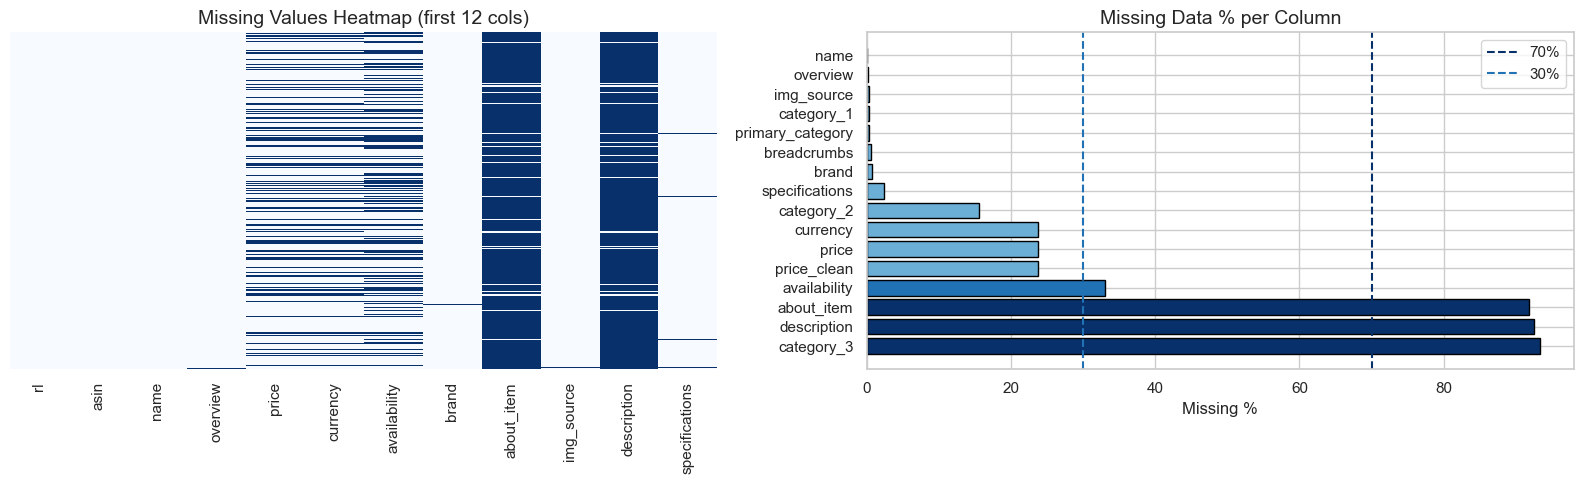

                  Missing Count  Missing Pct
category_3                 1349         93.4
description                1337         92.5
about_item                 1326         91.8
availability                478         33.1
price_clean                 344         23.8
price                       344         23.8
currency                    344         23.8
category_2                  226         15.6
specifications               35          2.4
brand                        10          0.7
breadcrumbs                   9          0.6
primary_category              6          0.4
category_1                    6          0.4
img_source                    6          0.4
overview                      3          0.2
name                          1          0.1


In [5]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap en paleta azul
sns.heatmap(
    df[df.columns[:12]].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]

# Diferentes tonos de azul según porcentaje de missing
colors_mv = [
    '#08306b' if v > 70 else    # azul oscuro
    '#2171b5' if v > 30 else    # azul medio
    '#6baed6'                   # azul claro
    for v in mv['Missing Pct']
]

axes[1].barh(
    mv.index,
    mv['Missing Pct'],
    color=colors_mv,
    edgecolor='black'
)

axes[1].axvline(70, color='#08306b', linestyle='--', label='70%')
axes[1].axvline(30, color='#2171b5', linestyle='--', label='30%')

axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4. Ingenieria de Caracteristicas (Feature Engineering)

<div style="background: #fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;"> 
<b> Ejemplo Cotidiano</b><br>
Un agente inmobiliario no solo utilizalos metros cuadrados brutos, sino tambien la ubicacion, la antiguedad y el estado. Nosotros hacemos lo mismo: extraemos la informacion mas valiosa del txt sin procesar categorias
</div>

In [6]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total features engineered: {len(df.columns)}')
print('\nPrice tier distribution:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total features engineered: 39

Price tier distribution:
price_tier
1_budget     107
2_low        286
3_mid        322
4_premium    260
5_luxury     126
Unknown      344


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Análisis univariado (Univariate Analysis) 📊

<div style="background: #fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;"> 
<b>Pregunta clave:</b><br>
    ¿Cómo es la distribución de precios? ¿Hay valores atípicos? ¿Los datos están sesgados?
</div>

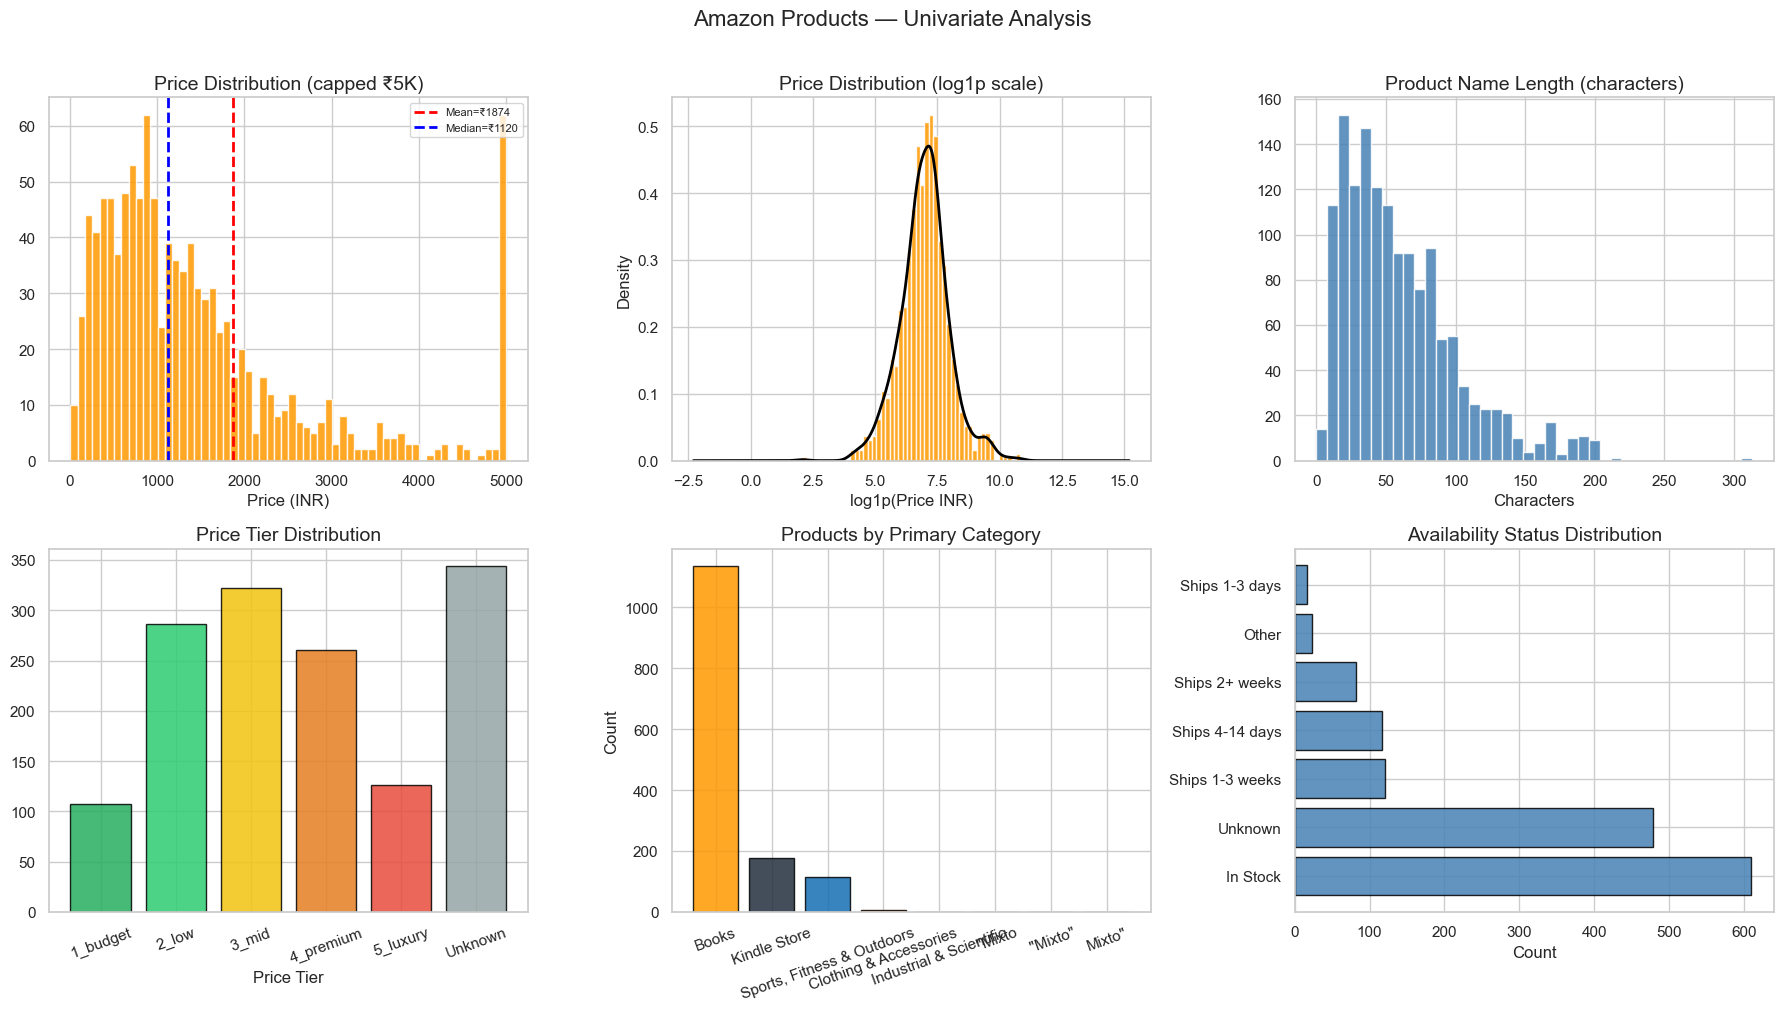

Shapiro-Wilk (log price, n=500): stat=0.9853, p=0.000059
Price is still non-normal after log transform

Price stats (INR):
count     1094.00
mean      1873.87
std       3330.33
min          7.00
25%        609.75
50%       1120.00
75%       1845.88
max      50555.00


In [7]:
# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price raw
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Mean=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Median=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Price Distribution (capped ₹5K)')
axes[0,0].set_xlabel('Price (INR)'); axes[0,0].legend(fontsize=8)

# Price log
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price INR)')

# Name length
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# Price tier
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier'); axes[1,0].tick_params(axis='x', rotation=20)

# Primary category
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count'); axes[1,1].tick_params(axis='x', rotation=20)

# Availability
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Normality test
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (log price, n=500): stat={stat:.4f}, p={p:.6f}')
print(f'Price is {"normally distributed after log transform" if p > 0.05 else "still non-normal after log transform"}')
print(f'\nPrice stats (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

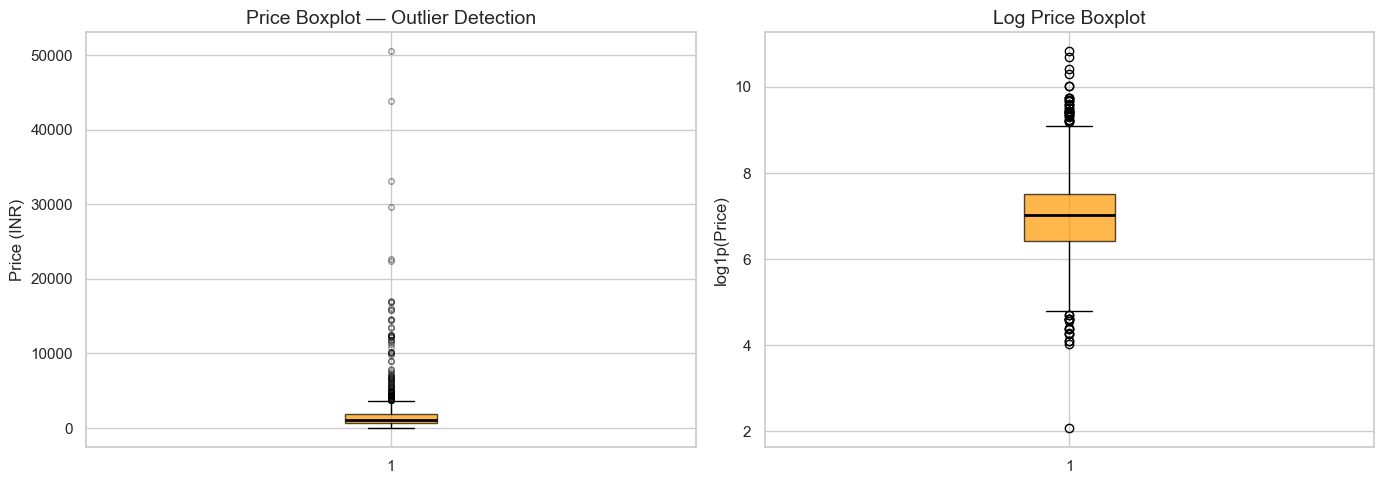

IQR method outliers: 93 (8.5%)
Price range (non-outlier): ₹-1244 – ₹3700

Top 10 most expensive products:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     29633.00                 

In [8]:
# Outlier analysis — boxplot and IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Price Boxplot — Outlier Detection')
axes[0].set_ylabel('Price (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Log Price Boxplot')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'IQR method outliers: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Price range (non-outlier): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nTop 10 most expensive products:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))

## 6. Análisis de categorías (Category Analysis) 🗂️

<div style="background: #fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;"> 
<b>Pregunta clave:</b><br>
    ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se encuentra la mejor relación calidad-precio?
</div>

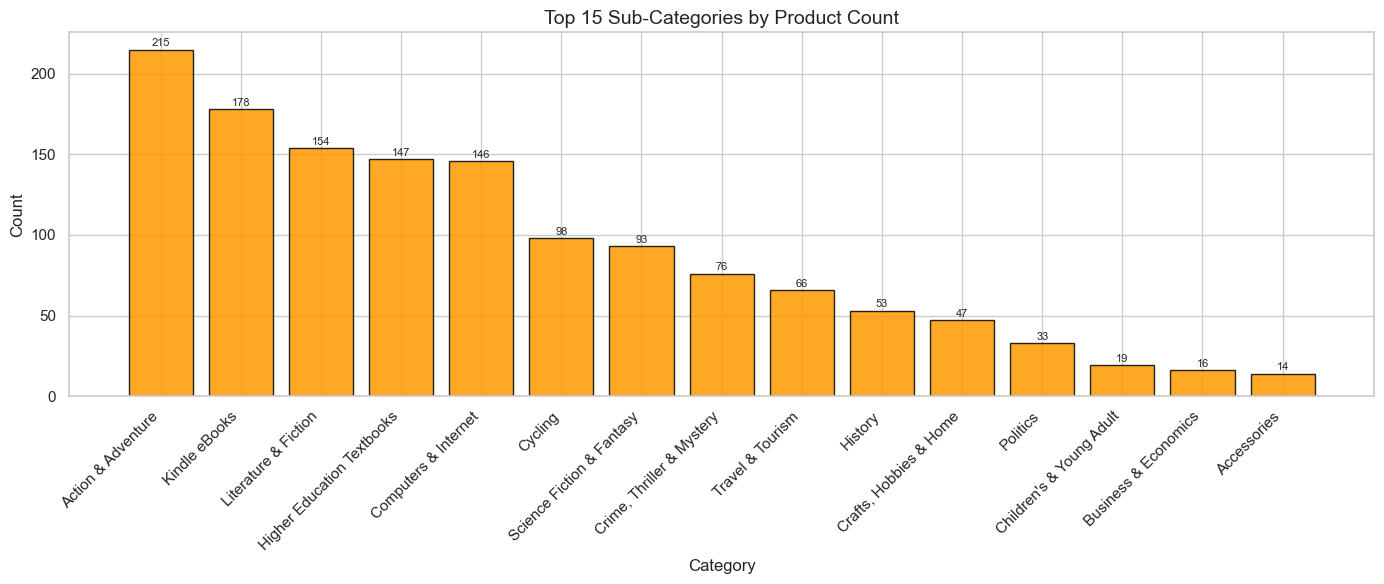

In [9]:
# ============================================================
# SECTION 5 — Category Analysis
# ============================================================
# Top 15 sub-categories by count
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

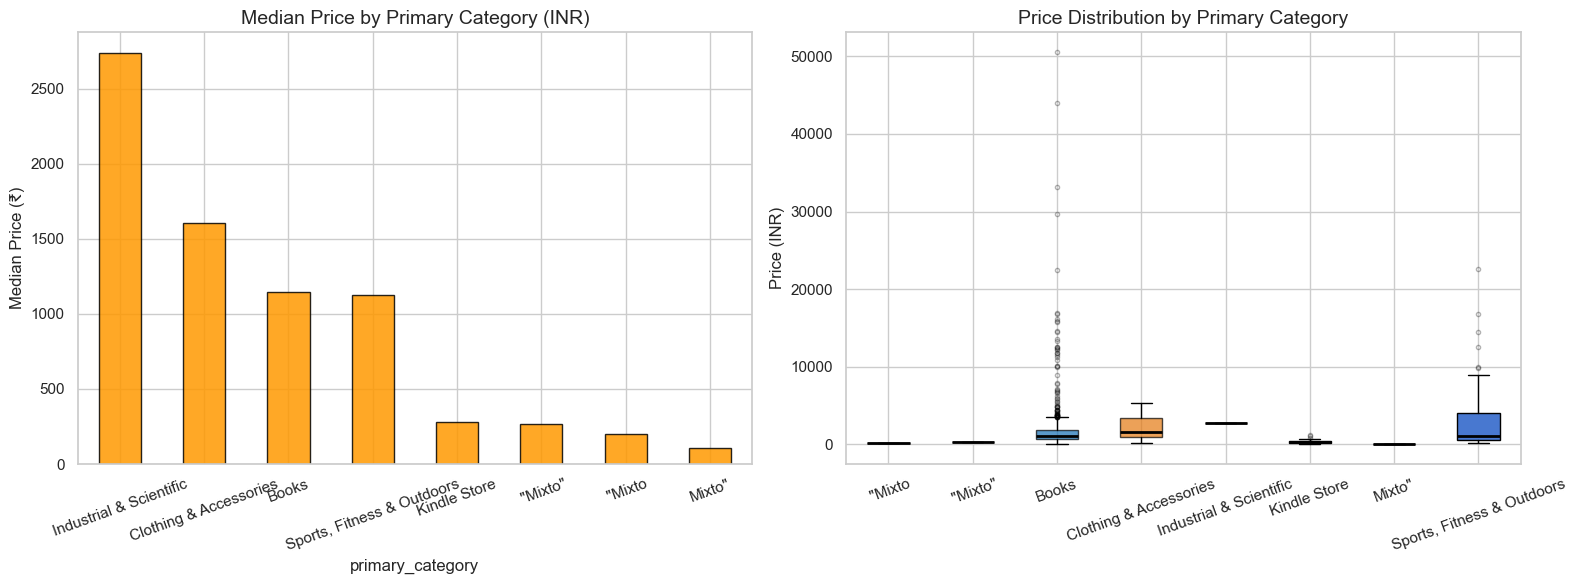

Price stats by primary category:
                              mean  median  count
primary_category                                 
 "Mixto                      199.0   199.0      1
 "Mixto"                     269.0   269.0      1
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Mixto"                       109.0   109.0      1
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [10]:
# Price by primary category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=20)

# Boxplot
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]
bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()
print('Price stats by primary category:')
print(cat_price.to_string())


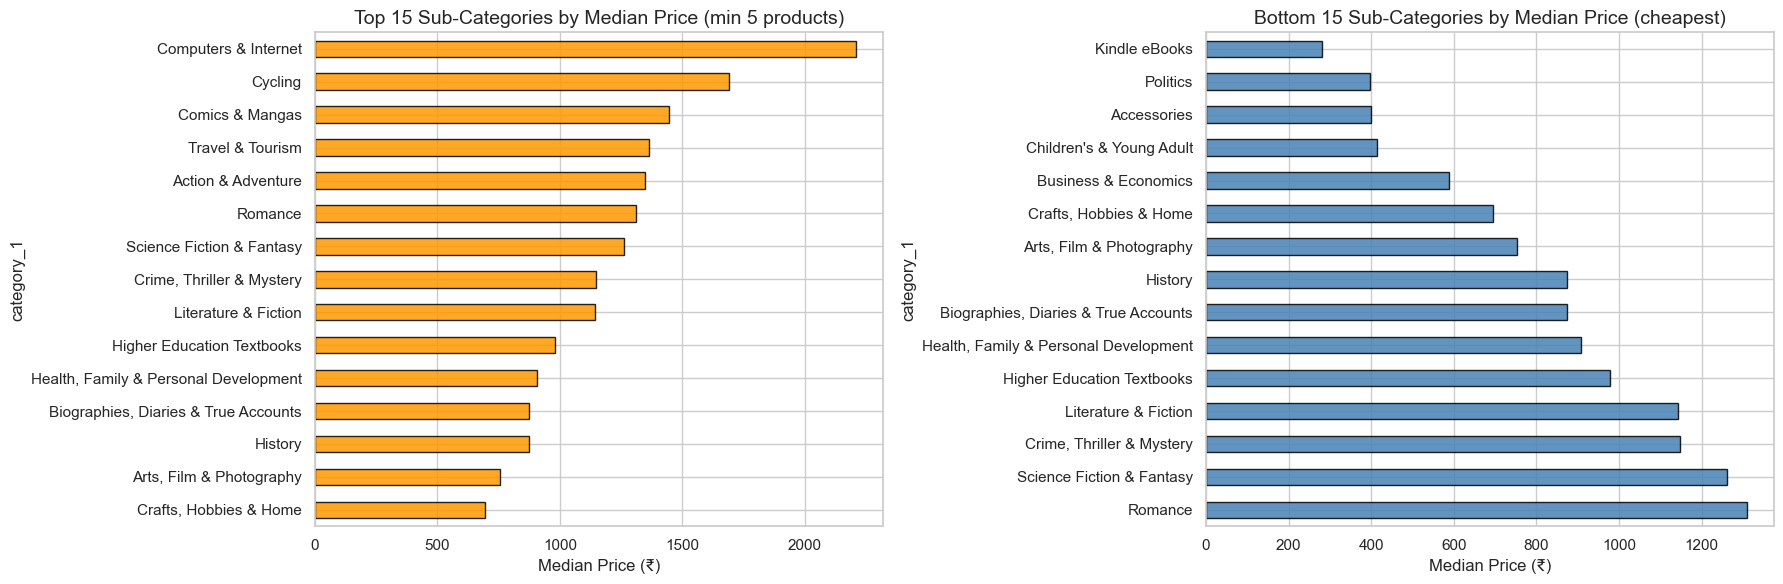

In [11]:
# Top 15 sub-categories by median price
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')

# Bottom 15 (cheapest)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')

plt.tight_layout(); plt.show()

## 7. Availability Analysis 📦

<div style="background: #fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;"> 
<b>Pregunta clave:</b><br>
   ¿Afecta la disponibilidad al precio? ¿Es más probable que los productos premium se agoten?
</div>

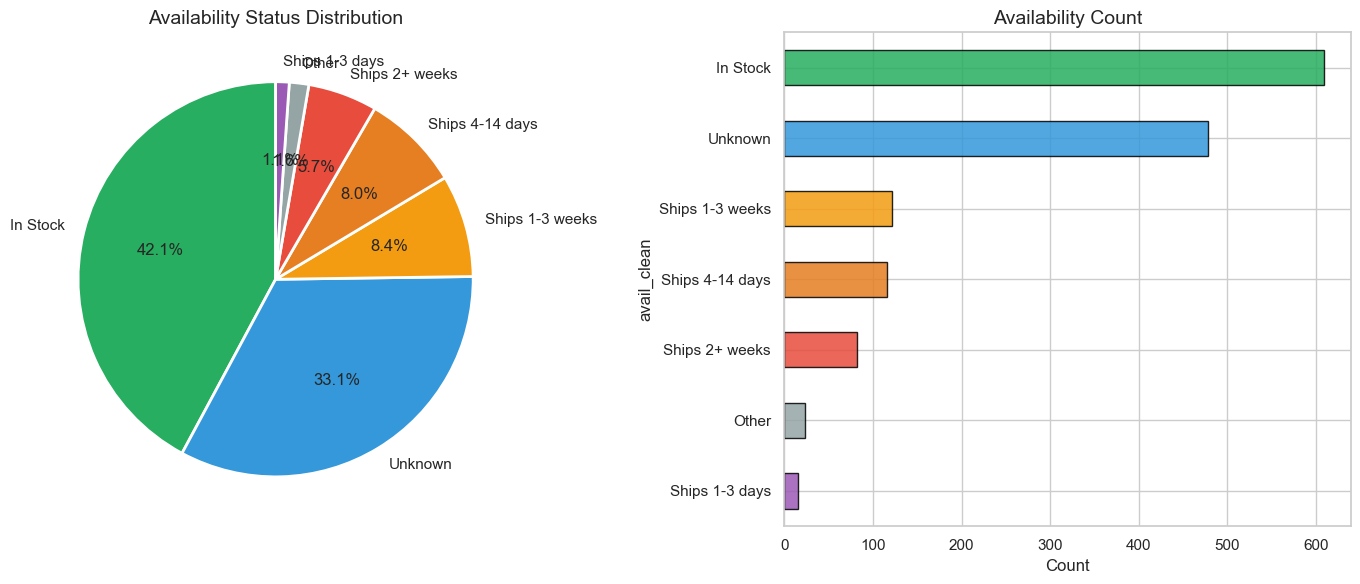

In [12]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Availability Status Distribution')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()

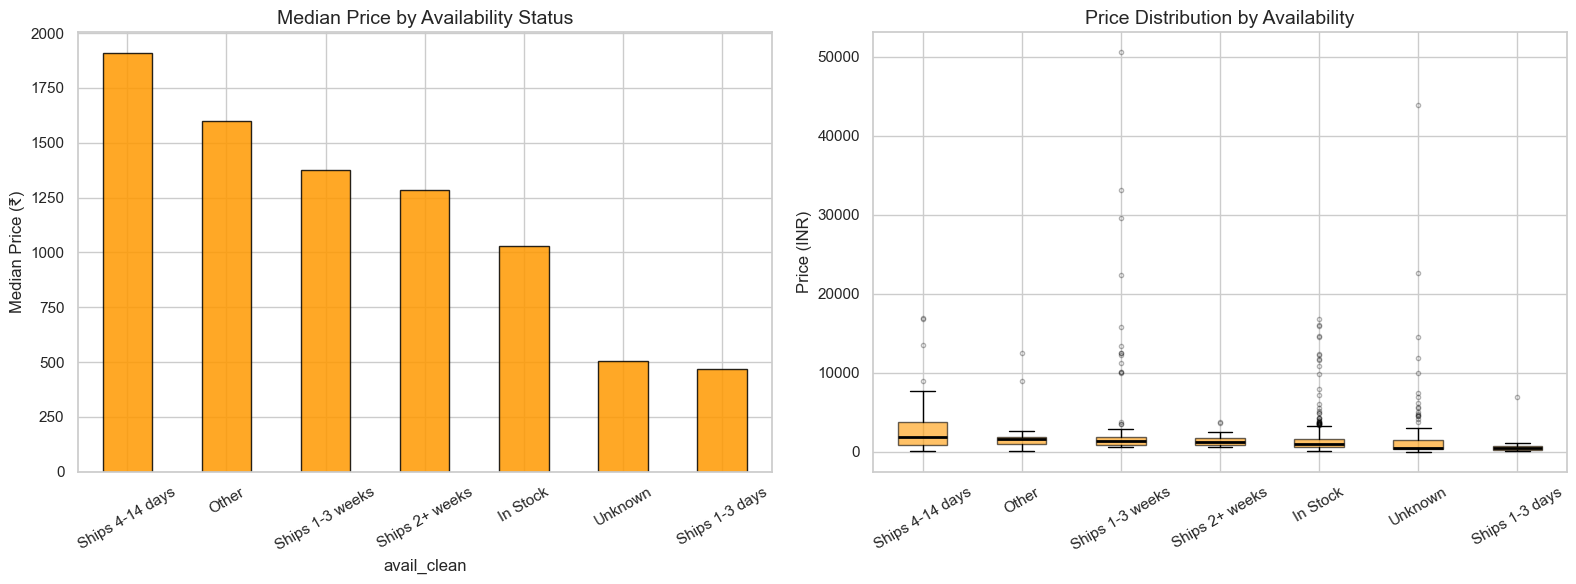

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1908.1  2861.7    116
Other            1600.0  2163.7     23
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1284.5  1386.8     82
In Stock         1030.0  1490.6    601
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [13]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())

## 8. Análisis de correlación y bivariado 🔗

<div style="background: #fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;"> 
<b>Pregunta clave:</b><br>
  ¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre predice el precio?
</div>


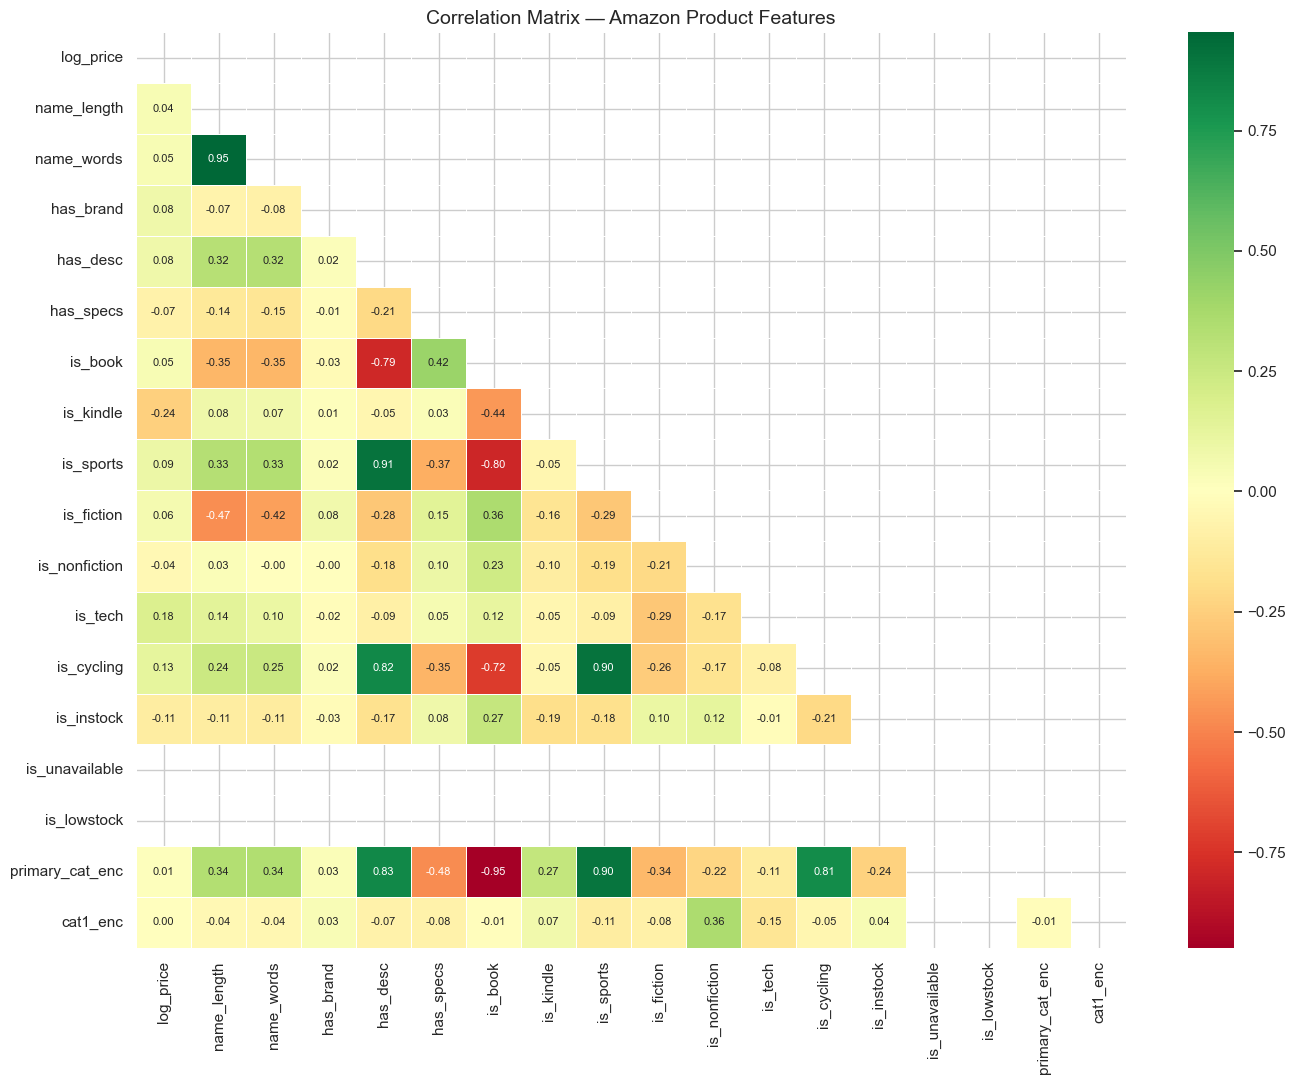

Top correlations with log_price:
is_tech            0.177210
is_cycling         0.127352
is_sports          0.092767
has_brand          0.082989
has_desc           0.081810
is_fiction         0.056820
is_book            0.045908
name_words         0.045819
name_length        0.040140
primary_cat_enc    0.011045
cat1_enc           0.001485
is_nonfiction     -0.041287
has_specs         -0.074325
is_instock        -0.107227
is_kindle         -0.244610
is_unavailable          NaN
is_lowstock             NaN


In [14]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

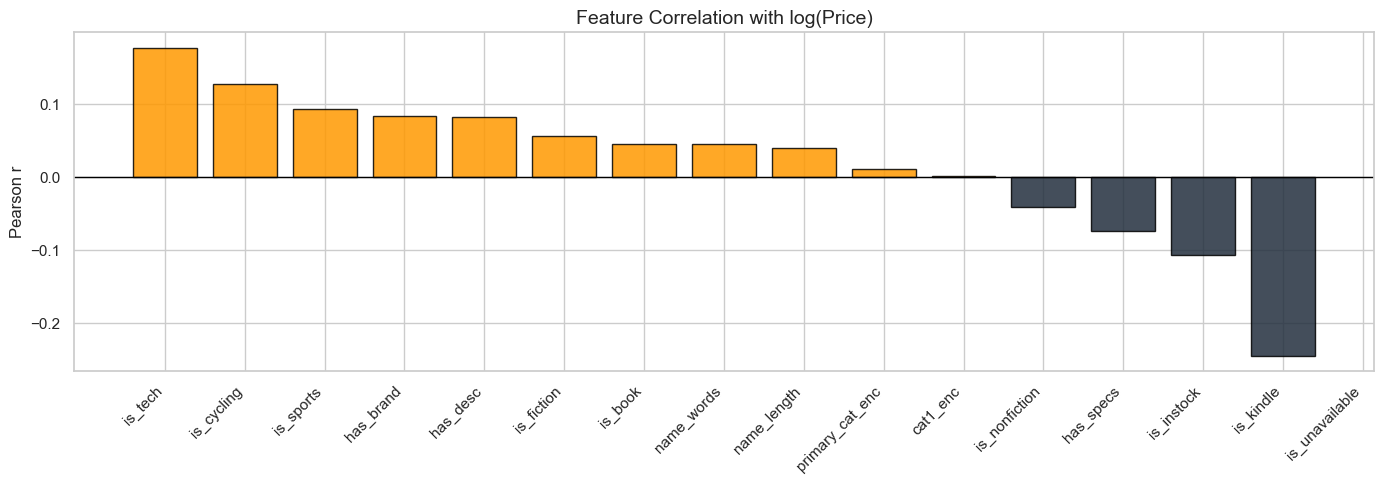

In [15]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

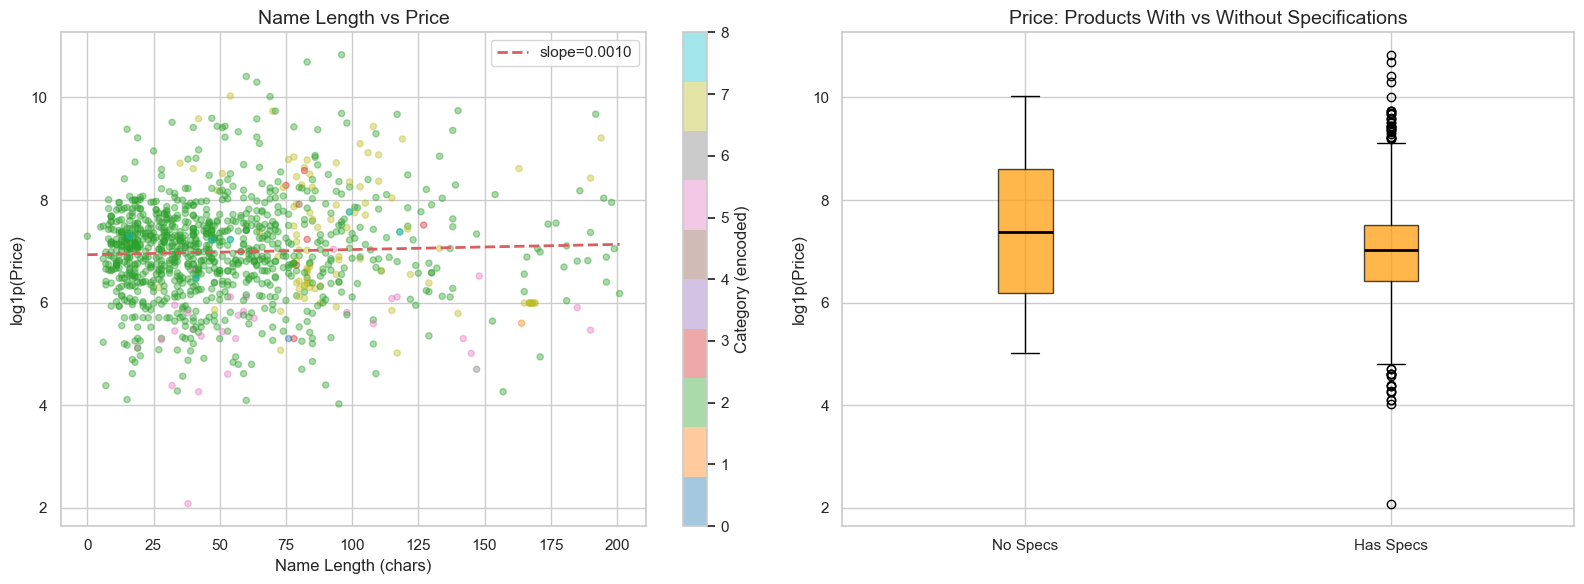

In [16]:
# Scatter: name length vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Category (encoded)')
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'slope={m:.4f}')
axes[0].set_xlabel('Name Length (chars)'); axes[0].set_ylabel('log1p(Price)')
axes[0].set_title('Name Length vs Price'); axes[0].legend()

# Price by has_specs
axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                 np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                labels=['No Specs','Has Specs'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Price: Products With vs Without Specifications')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

## 9. Prueba de hipótesis estadísticas

<div style="background: #fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;"> <br>Utilizamos pruebas no paramétricas (Kruskal-Wallis, U de Mann-Whitney) porque el precio presenta una distribución muy asimétrica y no normal. α = 0,05</b>

|#|Hipotesis|prueba|
|---|---|---|
|H1|El precio difiere significativamente entre las categorías principales| Kruskal-Wallis |
|H2| Los libros tienen un precio significativamente menor que los productos deportivos| Mann-Whitney U |
|H3| Los productos en stock tienen un precio diferente al de los que no están disponibles| Mann-Whitney U |
|H4| La longitud del nombre está correlacionada positivamente con el precio| Correlación de Spearman |
|H5| Los productos con especificaciones tienen un precio más alto| Mann-Whitney U|

In [17]:
# ============================================================
# SECTION 8 — Hypothesis Testing
# ============================================================
alpha = 0.05

def mw_test(name, a, b, la, lb):
    u, p = mannwhitneyu(a.dropna(), b.dropna(), alternative='two-sided')
    print(f'{name}')
    print(f'  {la}: n={len(a.dropna())}, median=₹{a.median():.0f}')
    print(f'  {lb}: n={len(b.dropna())}, median=₹{b.median():.0f}')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULT: {"✅ REJECT H0 — Significant difference." if p < alpha else "❌ FAIL TO REJECT H0."}')
    print()
    return p

# H1: Price across primary categories — Kruskal-Wallis
cat_groups_kw = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
                 for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
cat_labels_kw = [c for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
h1, p1 = kruskal(*cat_groups_kw)
print(f'H1: Price across Primary Categories — Kruskal-Wallis')
for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(g)}, median=₹{g.median():.0f}')
print(f'  H={h1:.4f}, p={p1:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Price differs across categories." if p1 < alpha else "❌ FAIL TO REJECT H0."}')
print()

# H2: Books vs Sports
p2 = mw_test('H2: Books vs Sports Products Price',
             df_priced[df_priced['is_book']==1]['price_clean'],
             df_priced[df_priced['is_sports']==1]['price_clean'],
             'Books', 'Sports')

# H3: In Stock vs Unavailable
p3 = mw_test('H3: In-Stock vs Unavailable Price',
             df_priced[df_priced['is_instock']==1]['price_clean'],
             df_priced[df_priced['is_unavailable']==1]['price_clean'],
             'In Stock', 'Unavailable')

# H4: Name length vs price — Spearman
rho4, p4 = spearmanr(df_priced['name_length'], df_priced['price_clean'])
print(f'H4: Name Length vs Price — Spearman Correlation')
print(f'  rho={rho4:.4f}, p={p4:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Significant correlation." if p4 < alpha else "❌ FAIL TO REJECT H0."}')
print()

# H5: Has specs vs no specs
p5 = mw_test('H5: Products With vs Without Specifications',
             df_priced[df_priced['has_specs']==1]['price_clean'],
             df_priced[df_priced['has_specs']==0]['price_clean'],
             'Has Specs', 'No Specs')

H1: Price across Primary Categories — Kruskal-Wallis
  Books                              : n=955, median=₹1145
  Sports, Fitness & Outdoors         : n=93, median=₹1125
  Kindle Store                       : n=30, median=₹281
  Clothing & Accessories             : n=6, median=₹1606
  H=55.8663, p=0.000000
  RESULT: ✅ REJECT H0 — Price differs across categories.

H2: Books vs Sports Products Price
  Books: n=955, median=₹1145
  Sports: n=93, median=₹1125
  Mann-Whitney U=40247, p=0.135443
  RESULT: ❌ FAIL TO REJECT H0.

H3: In-Stock vs Unavailable Price
  In Stock: n=601, median=₹1030
  Unavailable: n=0, median=₹nan
  Mann-Whitney U=nan, p=nan
  RESULT: ❌ FAIL TO REJECT H0.

H4: Name Length vs Price — Spearman Correlation
  rho=0.0290, p=0.338307
  RESULT: ❌ FAIL TO REJECT H0.

H5: Products With vs Without Specifications
  Has Specs: n=1067, median=₹1114
  No Specs: n=27, median=₹1600
  Mann-Whitney U=11462, p=0.069550
  RESULT: ❌ FAIL TO REJECT H0.



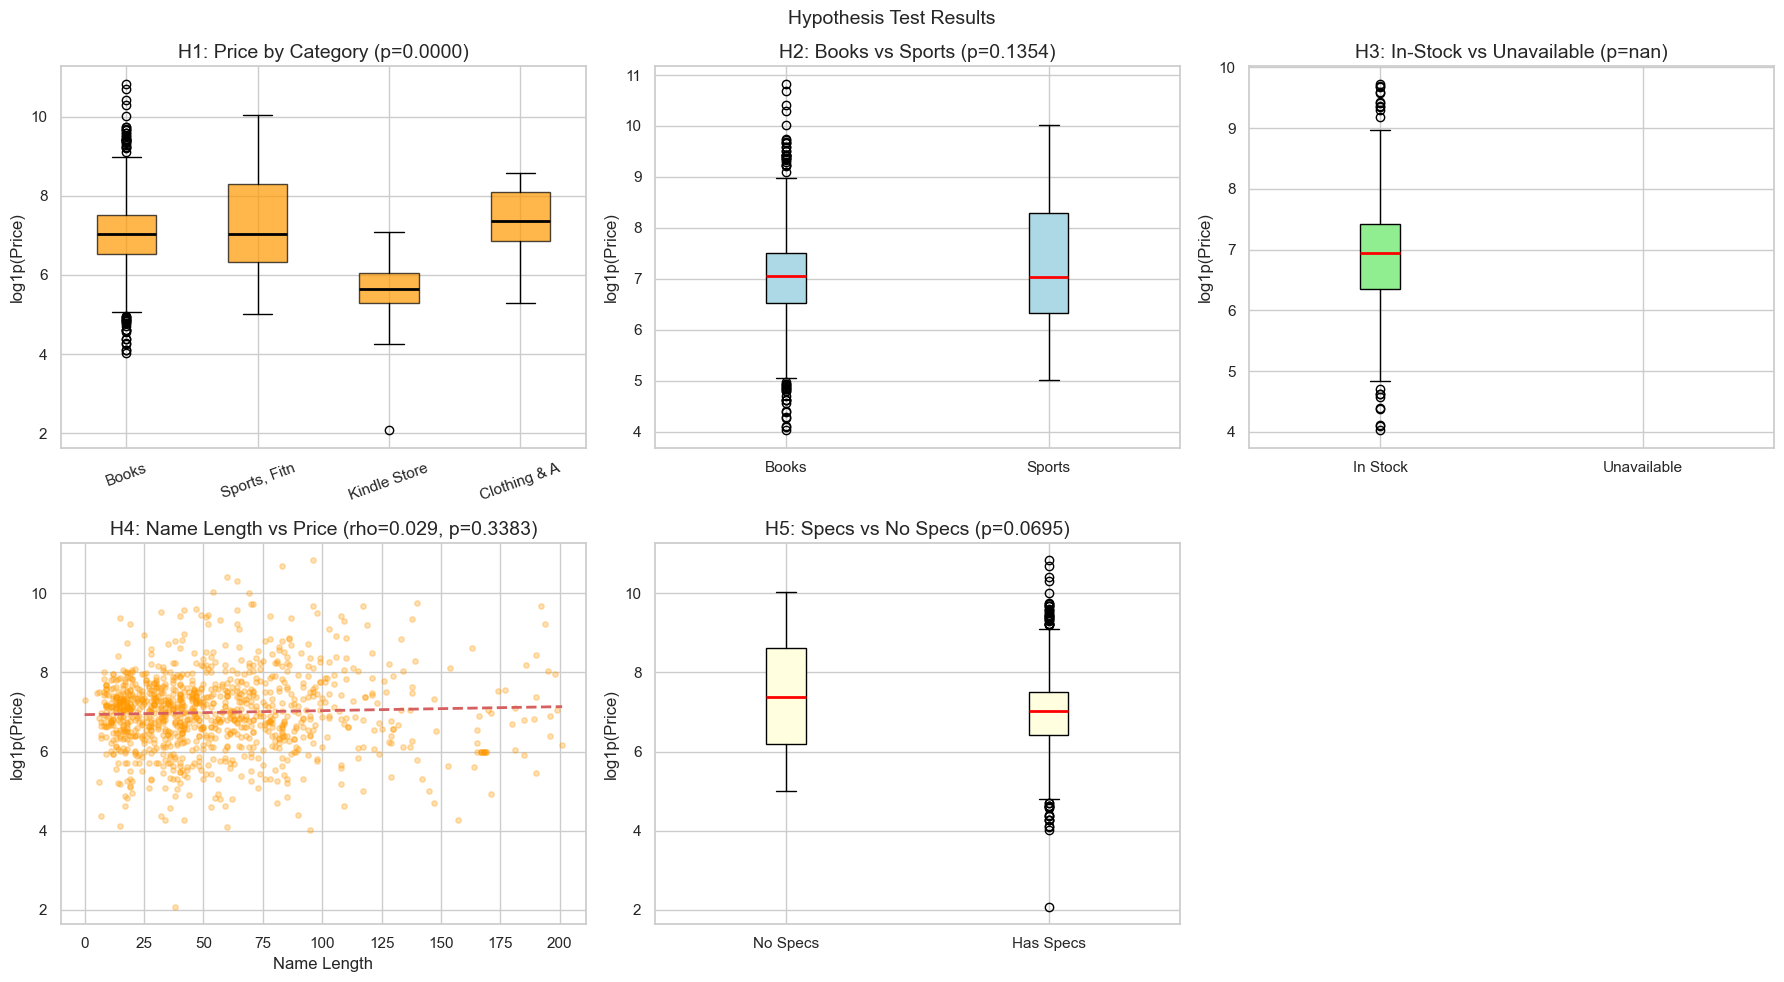

In [18]:
# Visualise hypothesis results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw],
                  labels=[l[:12] for l in cat_labels_kw], patch_artist=True,
                  boxprops=dict(facecolor='#FF9900', alpha=0.7),
                  medianprops=dict(color='black', lw=2))
axes[0,0].set_title(f'H1: Price by Category (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Price)'); axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])],
                  labels=['Books','Sports'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', lw=2))
axes[0,1].set_title(f'H2: Books vs Sports (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Price)')

# H3
axes[0,2].boxplot([np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])],
                  labels=['In Stock','Unavailable'], patch_artist=True,
                  boxprops=dict(facecolor='lightgreen'),
                  medianprops=dict(color='red', lw=2))
axes[0,2].set_title(f'H3: In-Stock vs Unavailable (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Price)')

# H4
axes[1,0].scatter(df_priced['name_length'], df_priced['log_price'],
                  alpha=0.3, color='#FF9900', s=15)
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[1,0].plot(x, m*x+b, 'r--', lw=2)
axes[1,0].set_title(f'H4: Name Length vs Price (rho={rho4:.3f}, p={p4:.4f})')
axes[1,0].set_xlabel('Name Length'); axes[1,0].set_ylabel('log1p(Price)')

# H5
axes[1,1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                   np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                  labels=['No Specs','Has Specs'], patch_artist=True,
                  boxprops=dict(facecolor='lightyellow'),
                  medianprops=dict(color='red', lw=2))
axes[1,1].set_title(f'H5: Specs vs No Specs (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Price)')

axes[1,2].set_visible(False)
plt.suptitle('Hypothesis Test Results', fontsize=14)
plt.tight_layout(); plt.show()

## ML Problem Framing  